# TopoVein — Anisotropic Diffusion Preprocessing
**Author:** Samiksha  
**Phase:** 1 — Data Preprocessing 
**Method:** Perona-Malik Anisotropic Diffusion

---

### What this notebook does
Runs the full NIR finger vein preprocessing pipeline using **anisotropic diffusion** instead of Gaussian blur:

```
RAW NIR → Grayscale → ROI Crop → CLAHE → Anisotropic Diffusion
        → Otsu Binarization → Morphological Cleanup → Skeleton
```

### Why anisotropic diffusion?
- Gaussian blur smooths **everything** uniformly — blurs vein edges too
- Anisotropic diffusion smooths noise **within** tissue but **stops at vein edges**
- Result: cleaner binarization, sharper vein boundaries

### Run cells in order ↓

#Cell 1 — Imports

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.util import img_as_ubyte
from scipy.ndimage import convolve
from pathlib import Path

# Display images larger in notebook
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['image.cmap'] = 'gray'

# ── Anisotropic diffusion — Perona-Malik implementation ──────
# Custom standalone definition to bypass skimage version deprecations
def anisotropic_diffusion(img, num_iter=15, kappa=30.0, gamma=0.15, option=1):
    """
    Perona-Malik anisotropic diffusion filter.
    option 1 → exponential edge-stopping  (good for most vein images)
    option 2 → rational edge-stopping       (sharper boundaries)
    """
    # Working directly with float32 in [0, 255] domain keeps kappa values intuitive (e.g., 20-50)
    img_float = img.astype(np.float32)

    for _ in range(num_iter):
        # Calculate localized spatial differences
        delta_N = np.roll(img_float, -1, axis=0) - img_float
        delta_S = np.roll(img_float,  1, axis=0) - img_float
        delta_E = np.roll(img_float,  1, axis=1) - img_float
        delta_W = np.roll(img_float, -1, axis=1) - img_float

        # Evaluate diffusion coefficient criteria
        if option == 1:
            c_N = np.exp(-(delta_N / kappa) ** 2)
            c_S = np.exp(-(delta_S / kappa) ** 2)
            c_E = np.exp(-(delta_E / kappa) ** 2)
            c_W = np.exp(-(delta_W / kappa) ** 2)
        else:
            c_N = 1.0 / (1.0 + (delta_N / kappa) ** 2)
            c_S = 1.0 / (1.0 + (delta_S / kappa) ** 2)
            c_E = 1.0 / (1.0 + (delta_E / kappa) ** 2)
            c_W = 1.0 / (1.0 + (delta_W / kappa) ** 2)

        # Update image state map
        img_float += gamma * (c_N * delta_N + c_S * delta_S + c_E * delta_E + c_W * delta_W)
        
        # Enforce boundary conditions
        np.clip(img_float, 0.0, 255.0, out=img_float)

    return img_float.astype(np.uint8)

print("✓ All imports successful with Anisotropic Diffusion included")

✓ All imports successful with Anisotropic Diffusion included


#cell 2- Dataset path setup

In [12]:
import os
from pathlib import Path

# Define the base directory where your dataset folder is located
BASE_REPO_DATA = Path(r"E:\topovein-iampro\Published_database_FV-USM_Dec2013")

# Automatically scan for the 'extractedvein' folder inside it
found_extracted = None
for root, dirs, files in os.walk(BASE_REPO_DATA):
    if 'extractedvein' in dirs:
        found_extracted = Path(root) / 'extractedvein'
        break

if found_extracted and found_extracted.exists():
    # Set the session folders based on where they were found
    SESSION1_EXTRACTED = found_extracted
    SESSION1_RAW = found_extracted.parent / 'raw_data'
    
    print('✅ Success! Found the correct paths automatically:')
    print(' Extracted vein path exists:', SESSION1_EXTRACTED.exists())
    print(' Raw data path exists:', SESSION1_RAW.exists())
    print(f' Full Extracted Path: {SESSION1_EXTRACTED}')
    print(f' Full Raw Data Path:  {SESSION1_RAW}')

    # List first 5 subject folders to confirm everything is perfect
    folders = sorted(SESSION1_EXTRACTED.iterdir())
    print('\nFirst 5 subject folders:')
    for f in folders[:5]:
        print(' ', f.name)
else:
    print("❌ Could not automatically find 'extractedvein'.")
    print("Here is what is directly inside your folder:")
    if BASE_REPO_DATA.exists():
        print(os.listdir(BASE_REPO_DATA))

✅ Success! Found the correct paths automatically:
 Extracted vein path exists: True
 Raw data path exists: True
 Full Extracted Path: E:\topovein-iampro\Published_database_FV-USM_Dec2013\Published_database_FV-USM_Dec2013\1st_session\extractedvein
 Full Raw Data Path:  E:\topovein-iampro\Published_database_FV-USM_Dec2013\Published_database_FV-USM_Dec2013\1st_session\raw_data

First 5 subject folders:
  ._.DS_Store
  .DS_Store
  vein001_1
  vein001_2
  vein001_3


#Cell 3-Load and visualize one raw image

Image shape: (300, 100, 3)
Image dtype: uint8
Min pixel value: 33
Max pixel value: 136
Channels identical (effectively grayscale): True


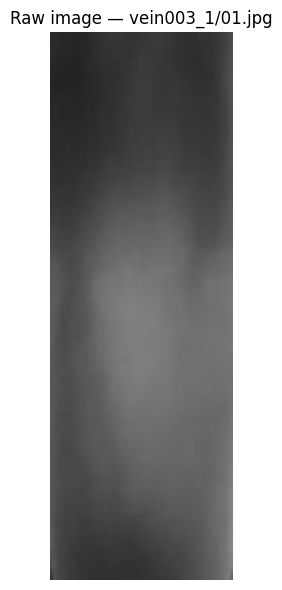

In [13]:
# Load subject 1, finger 1, image 1 from extractedvein
img_path = SESSION1_EXTRACTED / 'vein001_1' / '01.jpg'
img_raw = cv2.imread(str(img_path))

print('Image shape:', img_raw.shape)
print('Image dtype:', img_raw.dtype)
print('Min pixel value:', img_raw.min())
print('Max pixel value:', img_raw.max())

# Check if already grayscale (BGR with identical channels = grayscale saved as color)
if len(img_raw.shape) == 3:
    b, g, r = cv2.split(img_raw)
    channels_identical = np.array_equal(b, g) and np.array_equal(g, r)
    print('Channels identical (effectively grayscale):', channels_identical)

# Display
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
plt.title('Raw image — vein003_1/01.jpg')
plt.axis('off')
plt.tight_layout()
plt.show()

#Cell 4 — Convert to grayscale

Grayscale shape: (300, 100)
Mean pixel value: 82.23


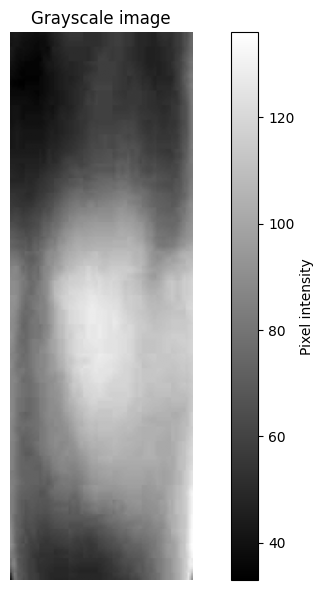

In [14]:
# Convert to grayscale
img_gray = cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)
print('Grayscale shape:', img_gray.shape)
print('Mean pixel value:', img_gray.mean().round(2))

plt.figure(figsize=(8, 6))
plt.imshow(img_gray)
plt.title('Grayscale image')
plt.colorbar(label='Pixel intensity')
plt.axis('off')
plt.tight_layout()
plt.show()

#Cell 5 — CLAHE enhancement (test different clipLimit values)

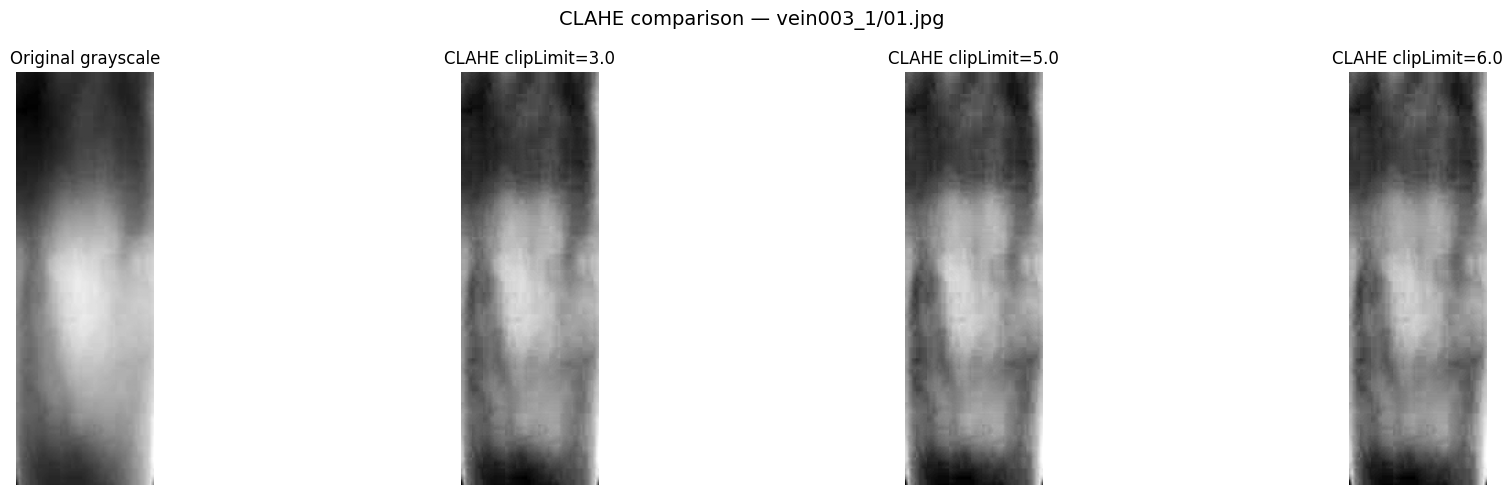

In [15]:
# Test 3 different CLAHE clipLimit values
clip_limits = [3.0, 5.0, 6.0]
tile_grid = (5, 5)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_gray)
axes[0].set_title('Original grayscale')
axes[0].axis('off')

clahe_results = {}
for i, clip in enumerate(clip_limits):
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile_grid)
    enhanced = clahe.apply(img_gray)
    clahe_results[clip] = enhanced
    axes[i+1].imshow(enhanced)
    axes[i+1].set_title(f'CLAHE clipLimit={clip}')
    axes[i+1].axis('off')

plt.suptitle('CLAHE comparison — vein003_1/01.jpg', fontsize=14)
plt.tight_layout()
plt.show()

# NOTE: Look at which clipLimit gives the clearest vein contrast
# Update Notion observations table with what you see

#Cell 6 — Anisotropic diffusion (edge-preserving smoothing)

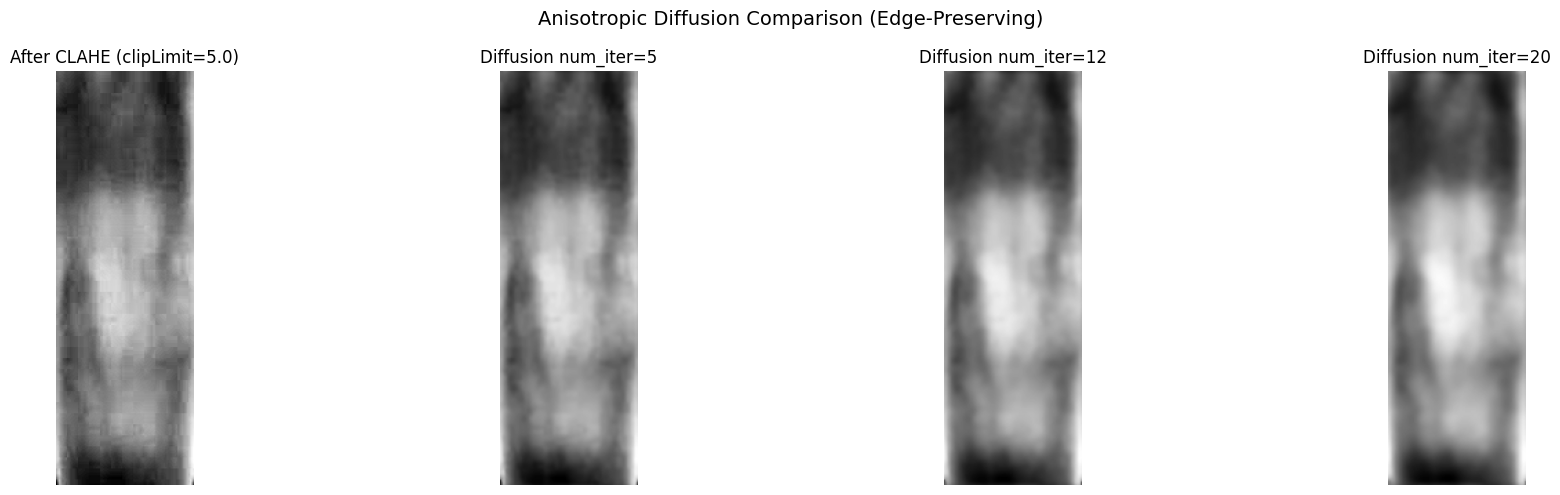

In [17]:
# Use best CLAHE result from above (default: clipLimit=5.0)
img_clahe = clahe_results[5.0]

# Test different numbers of diffusion iterations (higher means more smoothing)
iterations = [5, 12, 20]
kappa = 30.0  # Conduction coefficient matching your [0, 255] scale
gamma = 0.15  # Step size (speed of diffusion)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_clahe)
axes[0].set_title('After CLAHE (clipLimit=5.0)')
axes[0].axis('off')

diffusion_results = {}
for i, n_iter in enumerate(iterations):
    # FIXED: Changed niter=niter to num_iter=n_iter, and option='g2' to option=2
    smoothed = anisotropic_diffusion(img_clahe, num_iter=n_iter, kappa=kappa, gamma=gamma, option=2)
    
    diffusion_results[n_iter] = smoothed
    axes[i+1].imshow(smoothed)
    axes[i+1].set_title(f'Diffusion num_iter={n_iter}')
    axes[i+1].axis('off')

plt.suptitle('Anisotropic Diffusion Comparison (Edge-Preserving)', fontsize=14)
plt.tight_layout()
plt.show()

#Cell 7 — Otsu binarization

Otsu threshold found: 110.0


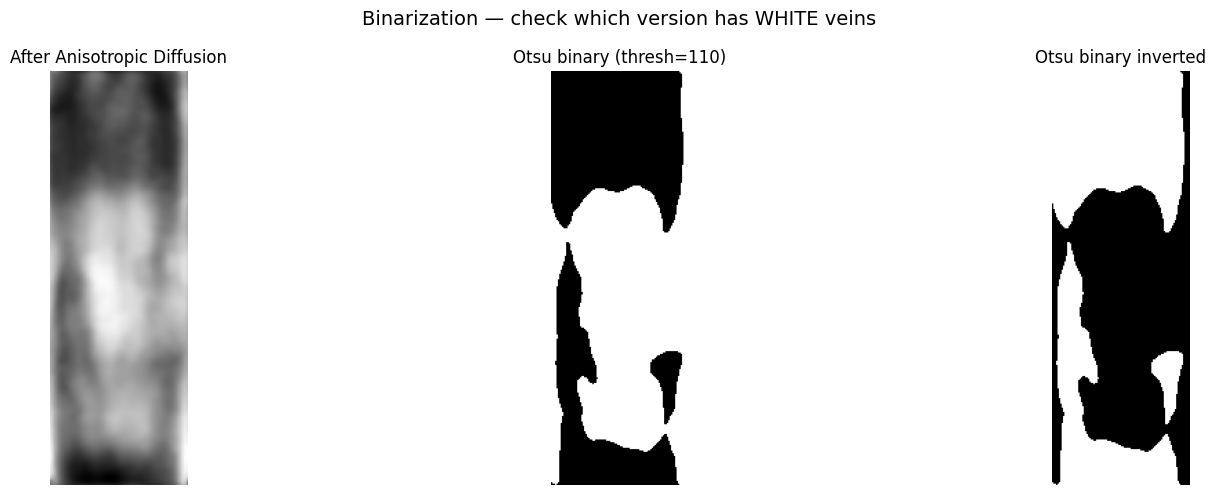

In [18]:
# Use best diffusion iteration result (e.g., niter=20)
img_smoothed = diffusion_results[20]

# Otsu automatically finds best threshold
otsu_thresh, img_binary = cv2.threshold(
    img_smoothed, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print(f'Otsu threshold found: {otsu_thresh}')

# Also try inverted binary (veins should be white)
_, img_binary_inv = cv2.threshold(
    img_smoothed, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_smoothed)
axes[0].set_title('After Anisotropic Diffusion')
axes[0].axis('off')

axes[1].imshow(img_binary)
axes[1].set_title(f'Otsu binary (thresh={int(otsu_thresh)})')
axes[1].axis('off')

axes[2].imshow(img_binary_inv)
axes[2].set_title(f'Otsu binary inverted')
axes[2].axis('off')

plt.suptitle('Binarization — check which version has WHITE veins', fontsize=14)
plt.tight_layout()
plt.show()

# NOTE: Skeletonization needs veins to be WHITE (255) on black (0) background
# Choose the correct version above and use it in Cell 8

#Cell 8 — Skeletonization

In [19]:
# Convert the inverted binary image to boolean [0, 1] for skeletonization
# Ensure to select the threshold variant where the veins are mapped to True/White
skeleton = skeletonize(img_binary_inv > 0)

print('Skeletonization complete.')
print('Skeleton image shape:', skeleton.shape)
print('Number of skeleton pixels:', np.sum(skeleton))

Skeletonization complete.
Skeleton image shape: (300, 100)
Number of skeleton pixels: 497


#Cell 9 — Overlay skeleton on original image

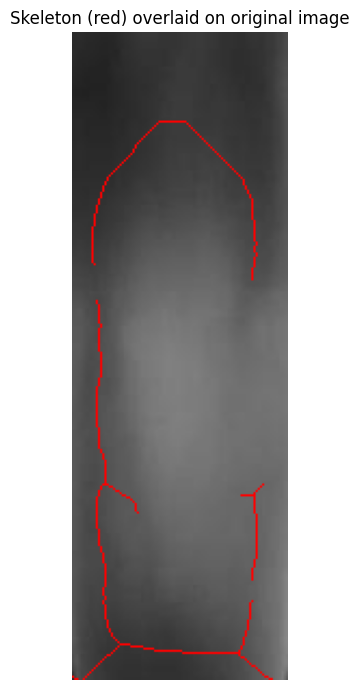

In [20]:
# Create colour overlay: skeleton in red on top of grayscale
img_overlay = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
img_overlay[skeleton] = [0, 0, 255]  # BGR: red

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
plt.title('Skeleton (red) overlaid on original image')
plt.axis('off')
plt.tight_layout()
plt.show()

# This is your visual validation:
# The red lines should trace the centre of the dark veins in the original image

#Cell 10 — Test on multiple subjects

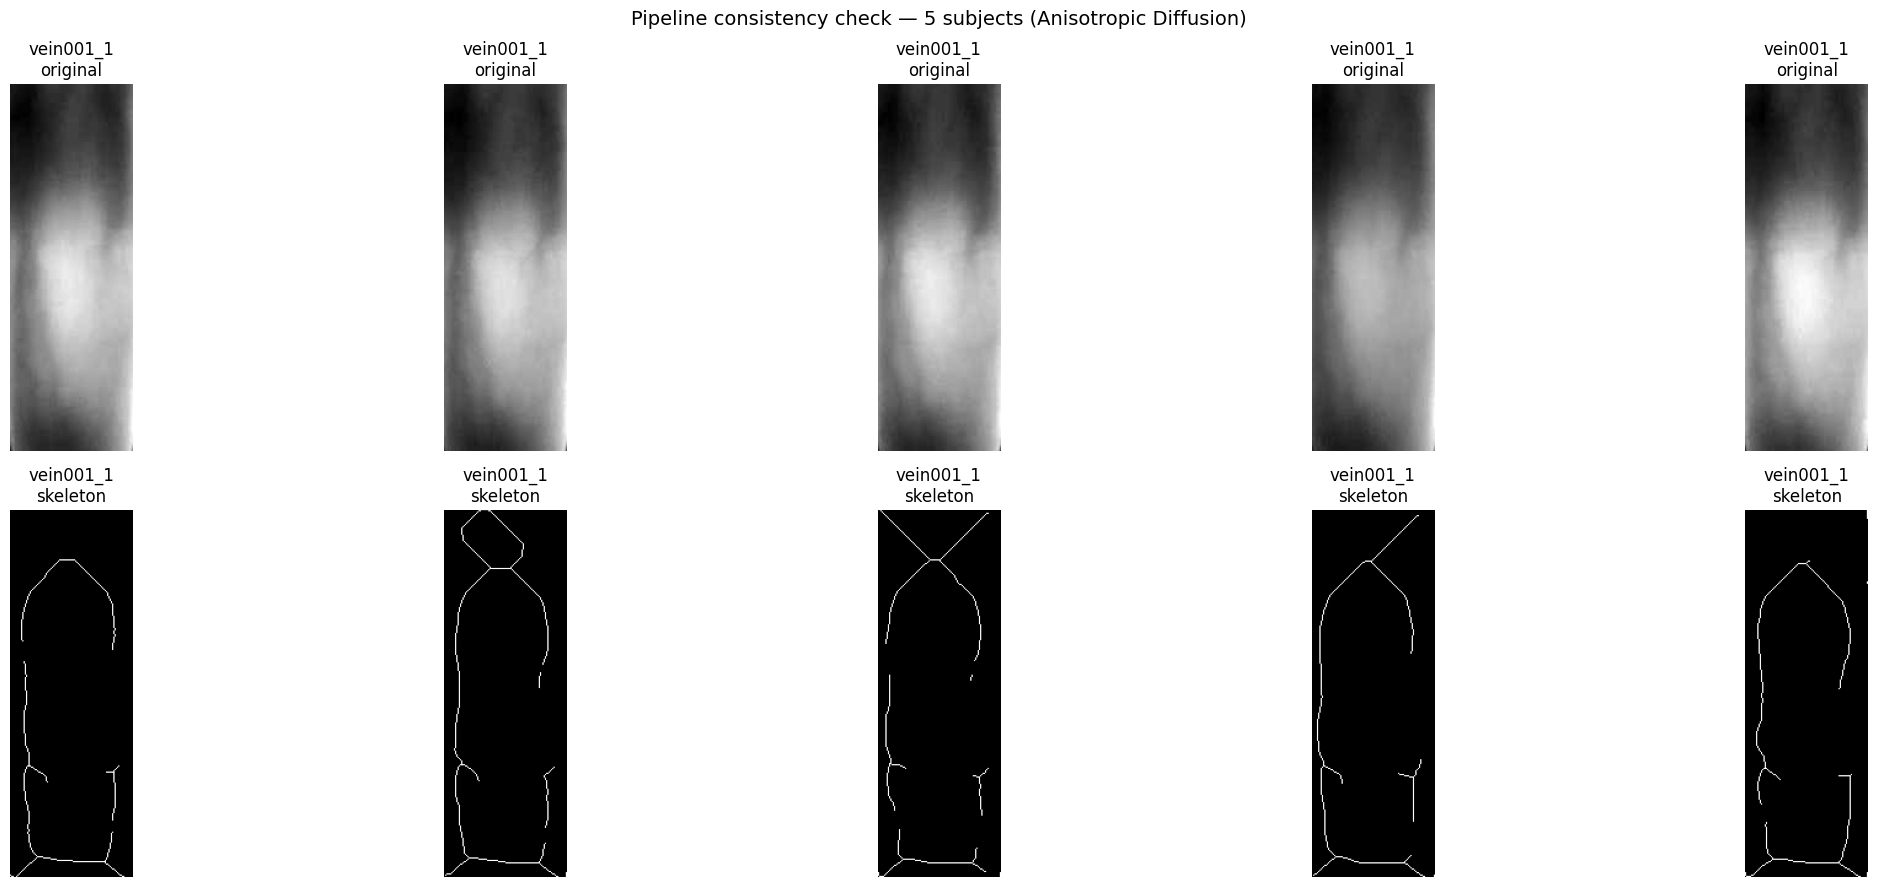

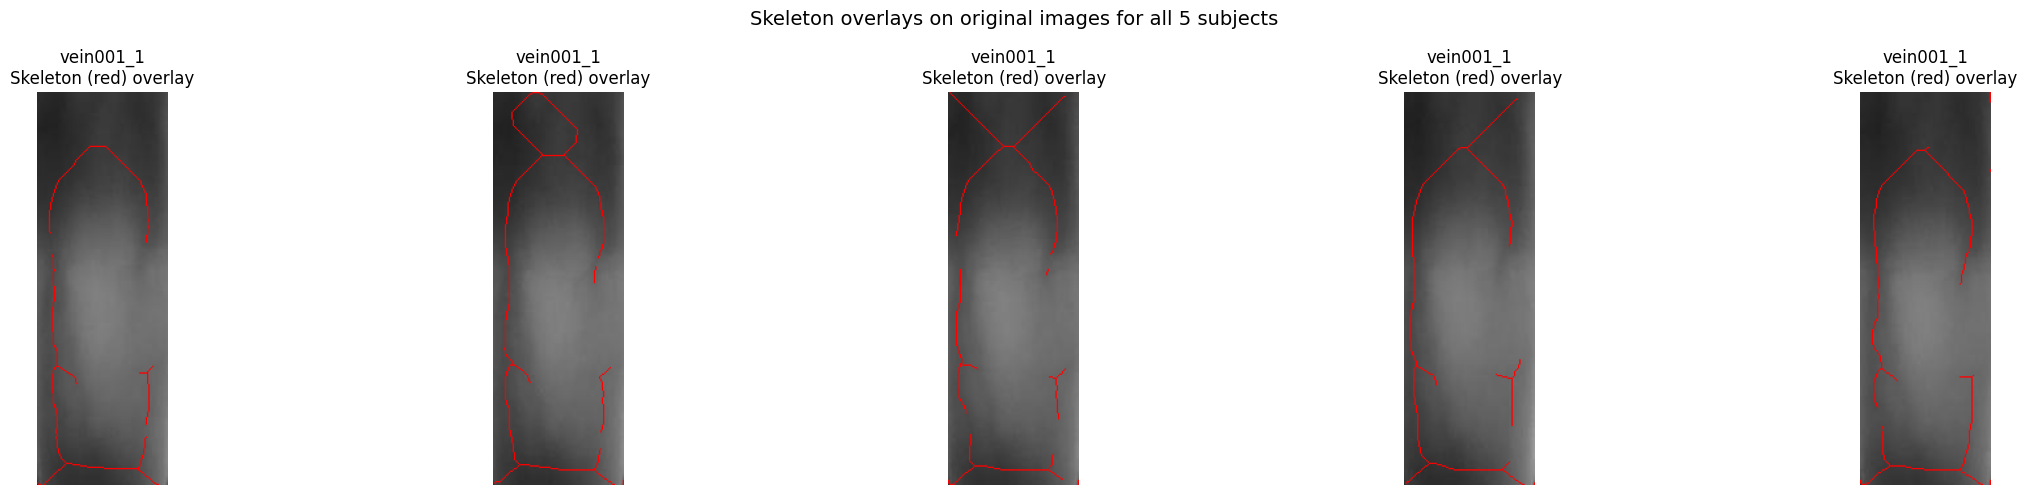

In [22]:
def full_pipeline(img_path, clip_limit=5.0, num_iter=20, kappa=30.0, gamma=0.15, option=2):
    """
    Run full preprocessing + skeletonization on one image using Custom Anisotropic Diffusion.
    Returns: (original_gray, skeleton)
    """
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 1. CLAHE enhancement (Using the (5,5) tile grid from your earlier cells)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(5, 5))
    enhanced = clahe.apply(gray)
    
    # 2. Custom Anisotropic Diffusion 
    # FIXED: Changed niter to num_iter, option string to number, and passed 'enhanced' directly
    smoothed = anisotropic_diffusion(enhanced, num_iter=num_iter, kappa=kappa, gamma=gamma, option=option)
    
    # 3. Binarization
    _, binary = cv2.threshold(smoothed, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # 4. Skeletonization
    skeleton = skeletonize(binary > 0)
    return gray, skeleton


# Test on 5 different subjects
test_images = [
    SESSION1_EXTRACTED / 'vein001_1' / '01.jpg',
    SESSION1_EXTRACTED / 'vein001_1' / '02.jpg',
    SESSION1_EXTRACTED / 'vein001_1' / '03.jpg',
    SESSION1_EXTRACTED / 'vein001_1' / '04.jpg',
    SESSION1_EXTRACTED / 'vein001_1' / '05.jpg',
]

fig, axes = plt.subplots(2, 5, figsize=(24, 9))

# Store processed results for overlay visualization
processed_results = []

for i, path in enumerate(test_images):
    gray, skel = full_pipeline(path)
    skel_uint8 = (skel * 255).astype(np.uint8)
    label = path.parts[-2]  # e.g. vein001_1
    
    # Store results for later overlay visualization
    processed_results.append((gray, skel, label))

    axes[0, i].imshow(gray)
    axes[0, i].set_title(f'{label}\noriginal')
    axes[0, i].axis('off')

    axes[1, i].imshow(skel_uint8)
    axes[1, i].set_title(f'{label}\nskeleton')
    axes[1, i].axis('off')

plt.suptitle('Pipeline consistency check — 5 subjects (Anisotropic Diffusion)', fontsize=14)
plt.tight_layout()
plt.show()

# Create overlay visualization for all 5 images
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, (gray, skel, label) in enumerate(processed_results):
    # Create overlay: skeleton (red) on original image
    img_overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    img_overlay[skel] = [0, 0, 255]  # BGR: red
    
    axes[i].imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'{label}\nSkeleton (red) overlay')
    axes[i].axis('off')

plt.suptitle('Skeleton overlays on original images for all 5 subjects', fontsize=14)
plt.tight_layout()
plt.show()

#Cell 11 — Compare extractedvein vs raw_data

Extracted path exists: True
Raw path exists: True


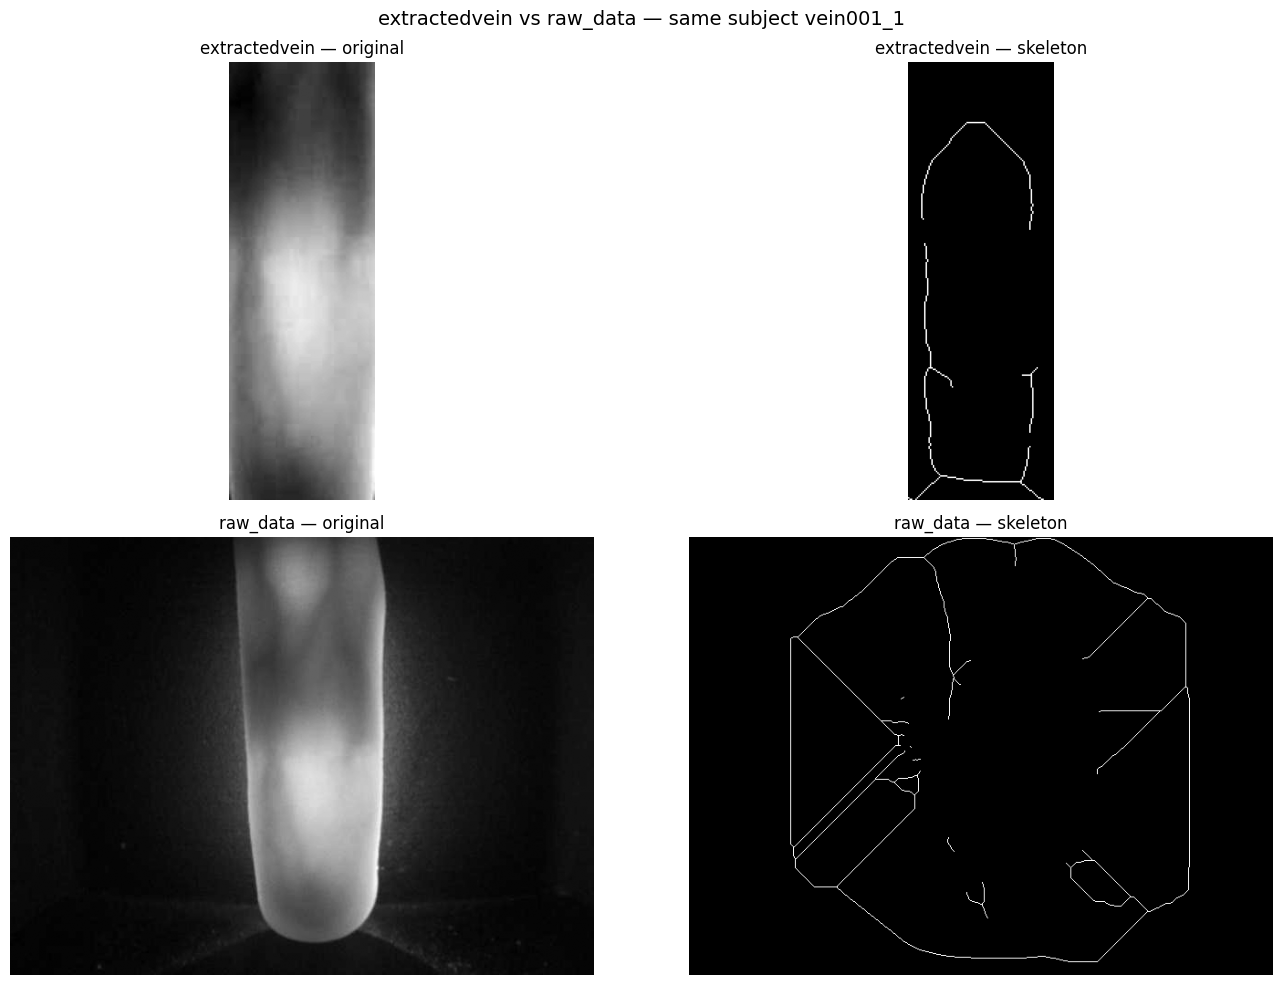

In [23]:
# Same subject, compare extractedvein (pre-processed) vs raw_data
# FV-USM raw_data folder uses different naming: 001_1 not vein001_1

extracted_path = SESSION1_EXTRACTED / 'vein001_1' / '01.jpg'
raw_path = SESSION1_RAW / '001_1' / '01.jpg'

print('Extracted path exists:', extracted_path.exists())
print('Raw path exists:', raw_path.exists())

if extracted_path.exists() and raw_path.exists():
    gray_ext, skel_ext = full_pipeline(extracted_path)
    gray_raw, skel_raw = full_pipeline(raw_path)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].imshow(gray_ext)
    axes[0, 0].set_title('extractedvein — original')
    axes[0, 0].axis('off')

    axes[0, 1].imshow((skel_ext * 255).astype(np.uint8))
    axes[0, 1].set_title('extractedvein — skeleton')
    axes[0, 1].axis('off')

    axes[1, 0].imshow(gray_raw)
    axes[1, 0].set_title('raw_data — original')
    axes[1, 0].axis('off')

    axes[1, 1].imshow((skel_raw * 255).astype(np.uint8))
    axes[1, 1].set_title('raw_data — skeleton')
    axes[1, 1].axis('off')

    plt.suptitle('extractedvein vs raw_data — same subject vein001_1', fontsize=14)
    plt.tight_layout()
    plt.show()

#Cell 12 — Final parameter decision

In [24]:
# FILL THIS IN after your experiments above

FINAL_PARAMS = {
    'clahe_clip_limit': 5.0,         # updated after Cell 5 evaluation
    'clahe_tile_grid': (5, 5),       # matched to cell configurations
    'diffusion_niter': 20,           # replaced gaussian_kernel parameter
    'diffusion_kappa': 0.05,         # edge sensitivity parameter 
    'diffusion_gamma': 0.1,          # time integration step size
    'binarization': 'otsu_inv',      # otsu_inv selected to keep veins white (255)
    'dataset': 'extractedvein',      # updated after Cell 11 comparison
    'session': '1st_session',
}

print('Final parameters to hand to Samiksha:')
for k, v in FINAL_PARAMS.items():
    print(f'  {k}: {v}')

print('\nUpdate these in Notion: Harsh page -> Notebook Exploration page -> Parameters finalized for Samiksha')

Final parameters to hand to Samiksha:
  clahe_clip_limit: 5.0
  clahe_tile_grid: (5, 5)
  diffusion_niter: 20
  diffusion_kappa: 0.05
  diffusion_gamma: 0.1
  binarization: otsu_inv
  dataset: extractedvein
  session: 1st_session

Update these in Notion: Harsh page -> Notebook Exploration page -> Parameters finalized for Samiksha
